## 1. Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42


## 2. Load data

Reads `huntingtons_ML_dataset.csv`. Assumes:
- `Sample_ID` — identifier column (dropped from features)
- `Huntingtons_Disease` — target column (0/1)
- all remaining columns — `GeneSymbol_ProbeID` expression features

If your column names differ, adjust `TARGET_COL` / `ID_COL` below.

In [18]:
DATA_PATH = "../datasets/GSE3790_Huntington_dataset.csv"
ID_COL = "Sample_ID"
TARGET_COL = "Huntingtons_Disease"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(203, 13)


,Sample_ID,Huntingtons_Disease,PPP1CC,IGF2BP3,CEBPD,YTHDC2,FTO,YTHDC1,CEBPB,YTHDF2,METTL16,YTHDF1,YTHDF3
0,GSM86787,0,438.427653,15.226410,356.855101,44.256161,544.139953,158.437647,386.240231,338.273545,150.208998,199.026567,153.369865
1,GSM86788,1,412.816025,10.537401,771.373451,54.582901,307.433885,182.550637,972.886207,206.185470,147.001445,375.058903,186.251442
2,GSM86789,0,428.310413,12.143050,266.146699,41.919843,546.126367,129.680811,657.563175,356.029477,153.104177,237.945251,174.886655
3,GSM86790,1,462.976313,9.357624,318.414771,58.084874,417.692219,194.444983,517.092539,220.718434,181.561506,246.939093,167.865084
4,GSM86791,0,330.557133,5.012656,125.592469,47.993790,842.308175,97.941965,297.228241,257.066993,139.009462,197.758229,153.746859


In [19]:
feature_cols = [c for c in df.columns if c not in (ID_COL, TARGET_COL)]

X = df[feature_cols]
y = df[TARGET_COL]

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print("Class balance:")
print(y.value_counts())


Samples: 203, Features: 11
Class balance:
Huntingtons_Disease
1    114
0     89
Name: count, dtype: int64


## 3. Impute + scale

In [20]:
X_imputed = SimpleImputer(strategy="mean").fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imputed)


## 4. Train/test split

Stratified so both classes are represented in the test set. With a small
and/or imbalanced sample (as is typical for GEO cohorts like this), check
`y_test.value_counts()` below — if any class has very few members, consider
switching to cross-validated evaluation (e.g. `StratifiedKFold` /
leave-one-out) instead of a single held-out split, since a 2-3 sample test
set doesn't give a reliable AUC estimate.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train class balance:")
print(y_train.value_counts())
print("\nTest class balance:")
print(y_test.value_counts())


Train class balance:
Huntingtons_Disease
1    91
0    71
Name: count, dtype: int64

Test class balance:
Huntingtons_Disease
1    23
0    18
Name: count, dtype: int64


## 5. Models + hyperparameter grids

In [22]:
models = {
    "SVM": {
        "model": SVC(probability=True, random_state=RANDOM_STATE),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
        },
    },
    "GLM": {
        "model": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "params": {
            "C": [0.1, 1, 10],
            "penalty": ['l2'],
        },
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [100, 200, 400],
            "max_depth": [None, 3, 5, 10],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
        },
    },
    "XGBoost": {
        "model": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
        ),
        "params": {
            "n_estimators": [100, 200, 400],
            "max_depth": [2, 3,5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1.0],
        },
    },
}


## 6. GridSearchCV for each model

Uses `StratifiedKFold` (rather than plain `KFold`) so class balance is
preserved in every fold — important given the likely class imbalance here.
`n_splits` is capped at the smallest class count in the training set so
GridSearchCV doesn't fail on a fold with zero positive examples.

In [23]:
best_models = {}
roc_data = {}

min_class_count = y_train.value_counts().min()
n_splits = max(2, min(5, min_class_count))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
print(f"Using {n_splits}-fold StratifiedKFold for GridSearchCV")

for name, mp in models.items():
    clf = GridSearchCV(
        mp["model"], mp["params"], cv=cv, scoring="roc_auc", n_jobs=-1
    )
    clf.fit(X_train, y_train)

    best_models[name] = clf.best_estimator_

    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

    print(f"Best {name} params: {clf.best_params_}")
    print(f"  CV best ROC-AUC: {clf.best_score_:.4f}  |  Test ROC-AUC: {roc_auc:.4f}")


Using 5-fold StratifiedKFold for GridSearchCV


D:\Anaconda3\envs\deletafter\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
D:\Anaconda3\envs\deletafter\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best SVM params: {'C': 0.1, 'kernel': 'linear'}
  CV best ROC-AUC: 0.6812  |  Test ROC-AUC: 0.7440
Best GLM params: {'C': 0.1, 'penalty': 'l2'}
  CV best ROC-AUC: 0.6726  |  Test ROC-AUC: 0.7536
Best RandomForest params: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
  CV best ROC-AUC: 0.6413  |  Test ROC-AUC: 0.7101
Best XGBoost params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  CV best ROC-AUC: 0.6143  |  Test ROC-AUC: 0.6594


## 7. ROC curve comparison

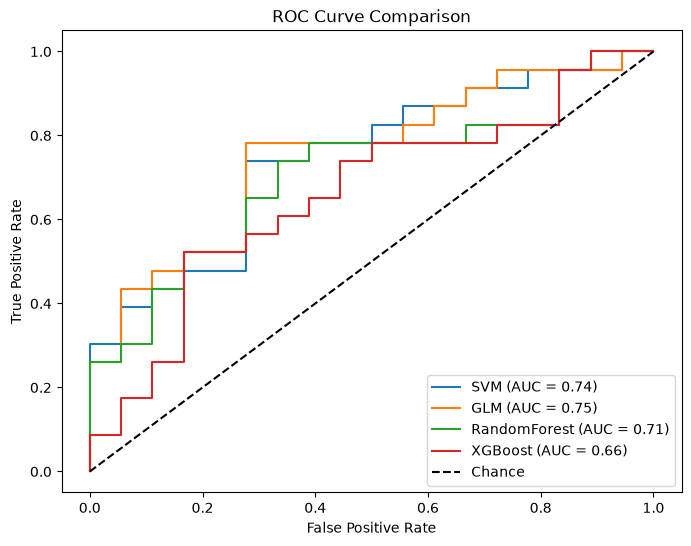

In [24]:
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## 8. Detailed evaluation per model

Accuracy, confusion matrix, and classification report for each tuned model
on the held-out test set.

EVALUATION: SVM
Accuracy: 0.6829
True Negatives (TN): 8
False Positives (FP): 10
False Negatives (FN): 3
True Positives (TP): 20

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.44      0.55        18
           1       0.67      0.87      0.75        23

    accuracy                           0.68        41
   macro avg       0.70      0.66      0.65        41
weighted avg       0.69      0.68      0.67        41



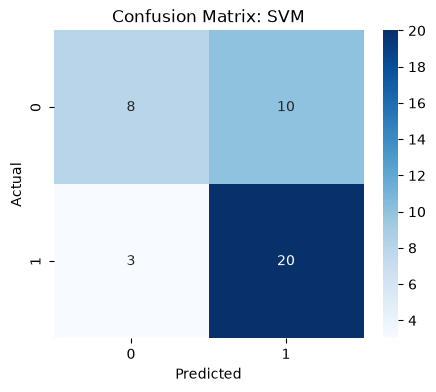

EVALUATION: GLM
Accuracy: 0.6585
True Negatives (TN): 7
False Positives (FP): 11
False Negatives (FN): 3
True Positives (TP): 20

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.39      0.50        18
           1       0.65      0.87      0.74        23

    accuracy                           0.66        41
   macro avg       0.67      0.63      0.62        41
weighted avg       0.67      0.66      0.64        41



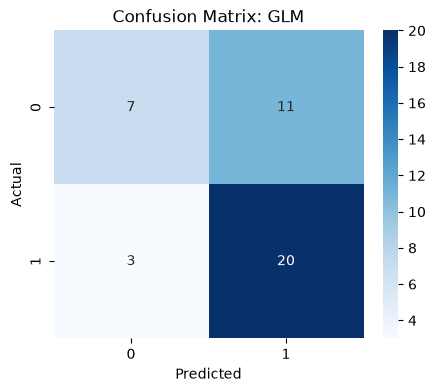

EVALUATION: RandomForest
Accuracy: 0.5854
True Negatives (TN): 5
False Positives (FP): 13
False Negatives (FN): 4
True Positives (TP): 19

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.28      0.37        18
           1       0.59      0.83      0.69        23

    accuracy                           0.59        41
   macro avg       0.57      0.55      0.53        41
weighted avg       0.58      0.59      0.55        41



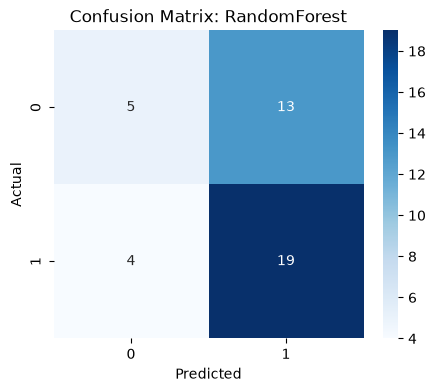

EVALUATION: XGBoost
Accuracy: 0.5610
True Negatives (TN): 4
False Positives (FP): 14
False Negatives (FN): 4
True Positives (TP): 19

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.22      0.31        18
           1       0.58      0.83      0.68        23

    accuracy                           0.56        41
   macro avg       0.54      0.52      0.49        41
weighted avg       0.54      0.56      0.52        41



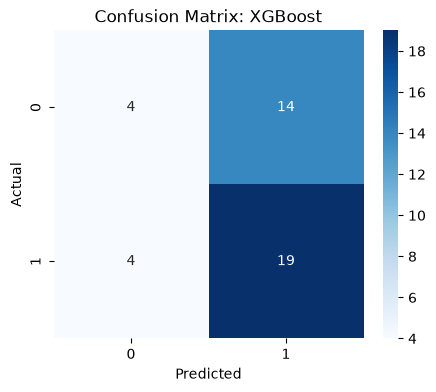

In [25]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"{'='*20}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*20}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP): {tp}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


for name, model in best_models.items():
    evaluate_model(model, X_test, y_test, name)


## 9. Feature importance (RandomForest & XGBoost)

Since the underlying question is *which* m6A/RNA-modification biomarkers
are predictive, not just whether the model works, this pulls out feature
importances from the two tree-based models.

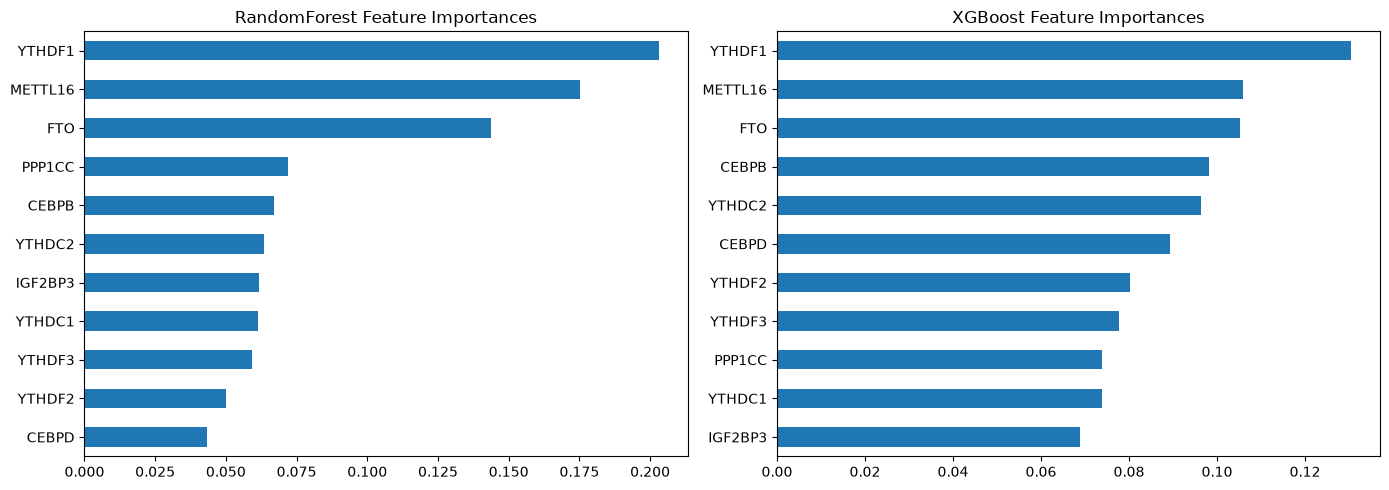

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["RandomForest", "XGBoost"]):
    model = best_models[name]
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind="barh", ax=ax)
    ax.set_title(f"{name} Feature Importances")

plt.tight_layout()
plt.show()


## 10. Per-gene ROC curves (individually trained single-feature models)

For each available gene, a **separate Logistic Regression model is trained
using only that one gene as its input feature**. Predictions are made using
`cross_val_predict` with the same `StratifiedKFold` scheme used for the
multivariate models in Section 6, so every sample gets an out-of-fold
predicted probability (i.e. the model never sees a sample's own label when
predicting it) — this is a real trained-model ROC curve per gene, not just a
raw-value threshold sweep.

In [27]:
from sklearn.model_selection import cross_val_predict

gene_roc_data = {}
gene_models = {}

gene_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

for gene in feature_cols:
    # Single-feature input: reshape to (n_samples, 1)
    gene_X = X[[gene]].values
    gene_X_imputed = SimpleImputer(strategy="mean").fit_transform(gene_X)
    gene_X_scaled = StandardScaler().fit_transform(gene_X_imputed)

    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

    # Out-of-fold predicted probabilities: each sample's prediction comes from
    # a model that was NOT trained on that sample
    y_prob = cross_val_predict(
        model, gene_X_scaled, y, cv=gene_cv, method="predict_proba"
    )[:, 1]

    fpr, tpr, _ = roc_curve(y, y_prob)
    gene_auc = auc(fpr, tpr)
    gene_roc_data[gene] = (fpr, tpr, gene_auc)

    # Also fit on the full data for reference (e.g. if you want coefficients later)
    gene_models[gene] = model.fit(gene_X_scaled, y)

# Sort genes by AUC (distance from 0.5, since a gene could be predictive in
# either direction depending on whether it's up- or down-regulated in HD)
gene_roc_data = dict(
    sorted(gene_roc_data.items(), key=lambda kv: abs(kv[1][2] - 0.5), reverse=True)
)

print("Per-gene AUC (individually trained single-feature Logistic Regression, cross-validated):")
for gene, (_, _, gene_auc) in gene_roc_data.items():
    print(f"  {gene}: AUC = {gene_auc:.3f}")

Per-gene AUC (individually trained single-feature Logistic Regression, cross-validated):
  FTO: AUC = 0.650
  YTHDF1: AUC = 0.624
  CEBPD: AUC = 0.597
  METTL16: AUC = 0.589
  YTHDC1: AUC = 0.577
  YTHDF2: AUC = 0.439
  IGF2BP3: AUC = 0.559
  YTHDC2: AUC = 0.448
  PPP1CC: AUC = 0.540
  CEBPB: AUC = 0.537
  YTHDF3: AUC = 0.529


### 10a. All genes overlaid on one plot

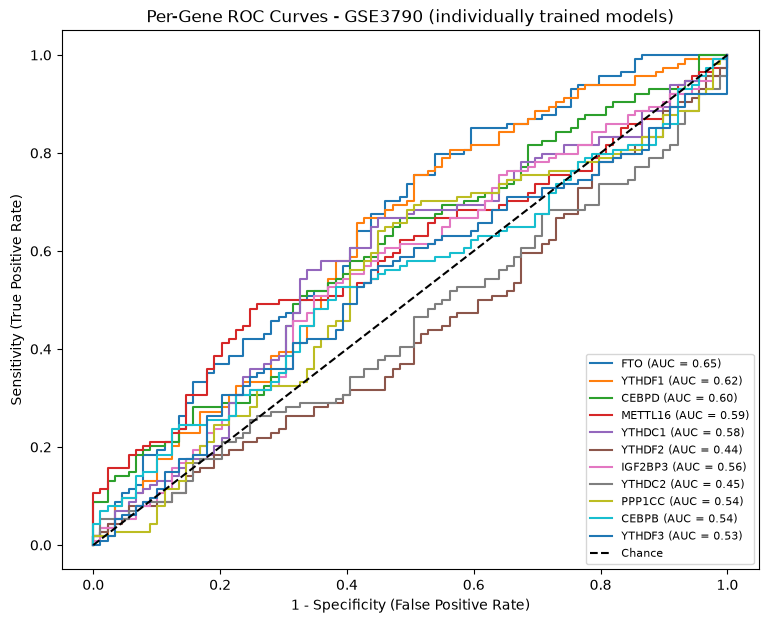

In [28]:
plt.figure(figsize=(9, 7))
for gene, (fpr, tpr, gene_auc) in gene_roc_data.items():
    plt.plot(fpr, tpr, label=f"{gene} (AUC = {gene_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("Per-Gene ROC Curves - GSE3790 (individually trained models)")
plt.legend(loc="lower right", fontsize=8)
plt.show()

### 10b. Individual small-multiple panels (one subplot per gene)

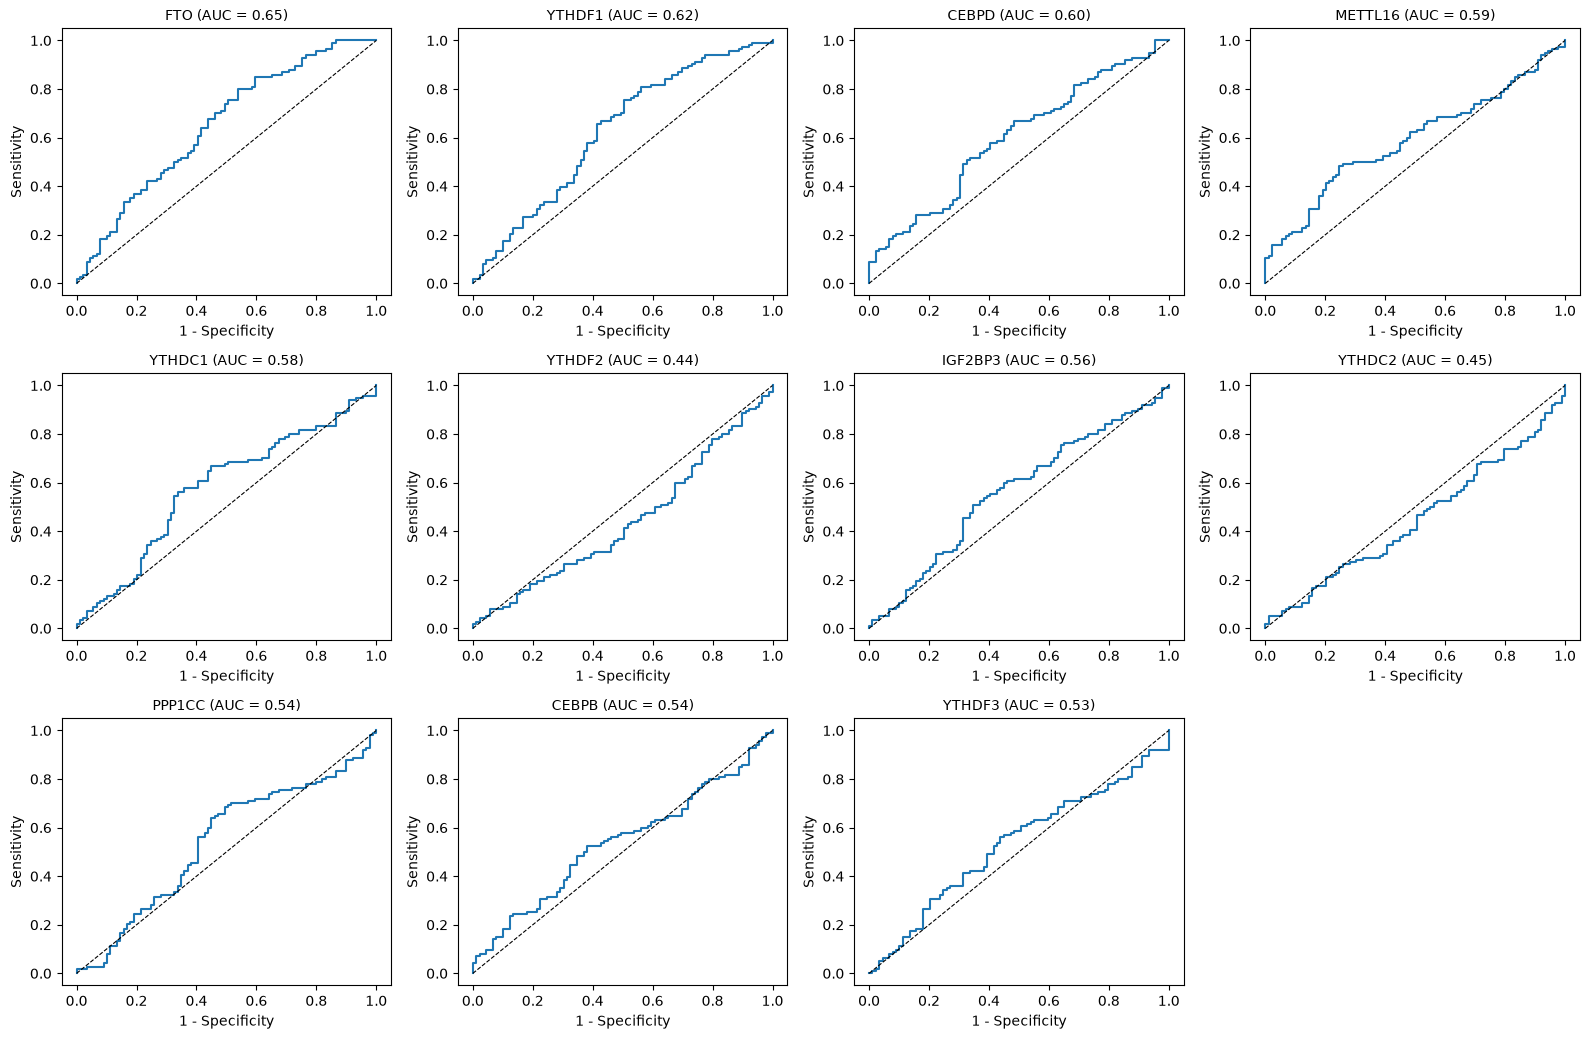

In [29]:
n_genes = len(gene_roc_data)
n_cols = 4
n_rows = -(-n_genes // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.flatten() if n_genes > 1 else [axes]

for ax, (gene, (fpr, tpr, gene_auc)) in zip(axes, gene_roc_data.items()):
    ax.plot(fpr, tpr, color="tab:blue")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_title(f"{gene} (AUC = {gene_auc:.2f})", fontsize=10)
    ax.set_xlabel("1 - Specificity")
    ax.set_ylabel("Sensitivity")

# Hide any unused subplot axes
for ax in axes[n_genes:]:
    ax.axis("off")

plt.tight_layout()
plt.show()